In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [178]:
data = pd.read_csv("../data/raw/Amazon Sale Report.csv")

C:\Users\altam\AppData\Local\Temp\ipykernel_14252\3426902795.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/raw/Amazon Sale Report.csv")


In [179]:
pd.set_option('display.max_columns', None)

In [180]:
data.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [181]:
data.shape

(128975, 24)

In [182]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [183]:
data.drop(columns=['Unnamed: 22', 'fulfilled-by', 'ship-country', 'currency', 'Order ID', 'index'], inplace=True)

In [184]:
data.shape

(128975, 18)

In [185]:
date = pd.to_datetime(data['Date'], format='%m-%d-%y')
data['Date'] = date

In [186]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                128975 non-null  datetime64[us]
 1   Status              128975 non-null  str           
 2   Fulfilment          128975 non-null  str           
 3   Sales Channel       128975 non-null  str           
 4   ship-service-level  128975 non-null  str           
 5   Style               128975 non-null  str           
 6   SKU                 128975 non-null  str           
 7   Category            128975 non-null  str           
 8   Size                128975 non-null  str           
 9   ASIN                128975 non-null  str           
 10  Courier Status      122103 non-null  str           
 11  Qty                 128975 non-null  int64         
 12  Amount              121180 non-null  float64       
 13  ship-city           128942 non-null  str

In [187]:
data.drop('B2B', axis = 1, inplace = True)

In [188]:
# check shape
data.shape

(128975, 17)

In [189]:
data['months'] = data['Date'].dt.month
data['years'] = data['Date'].dt.year

# check shape
data.shape

(128975, 19)

# Visualize sales by month

In [190]:
data.groupby('months')['Amount'].sum()

months
3      101683.85
4    28838708.32
5    26226476.75
6    23425809.38
Name: Amount, dtype: float64

<Axes: xlabel='months'>

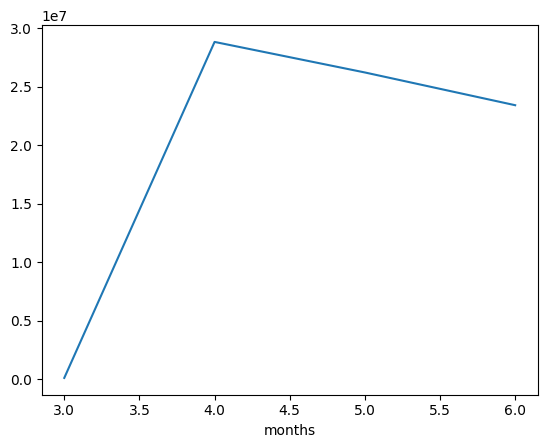

In [191]:
# Bar Graph

data.groupby('months')['Amount'].sum().plot(kind='line')

In [192]:
# top to low
data.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64

<Axes: xlabel='Category'>

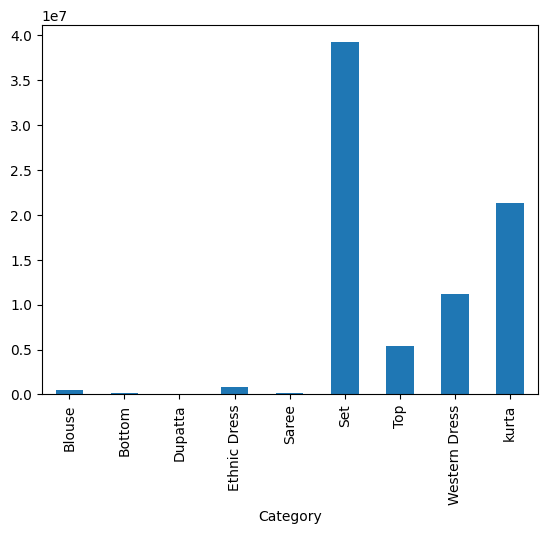

In [193]:
# top to low
data.groupby('Category')['Amount'].sum().plot(kind='bar')

In [194]:
data.groupby('ship-state')['Amount'].sum()

ship-state
ANDAMAN & NICOBAR      158723.62
ANDHRA PRADESH        3219831.72
APO                         0.00
AR                        493.00
ARUNACHAL PRADESH       95235.00
                         ...    
goa                      2467.00
orissa                    597.00
punjab                   8622.00
rajasthan                3946.00
rajsthan                  521.00
Name: Amount, Length: 69, dtype: float64

In [195]:
data['ship-state'] = data['ship-state'].str.upper().str.strip()

In [196]:
data['ship-state'].unique()

<StringArray>
[           'MAHARASHTRA',              'KARNATAKA',             'PUDUCHERRY',
             'TAMIL NADU',          'UTTAR PRADESH',             'CHANDIGARH',
              'TELANGANA',         'ANDHRA PRADESH',              'RAJASTHAN',
                  'DELHI',                'HARYANA',                  'ASSAM',
              'JHARKHAND',           'CHHATTISGARH',                 'ODISHA',
                 'KERALA',         'MADHYA PRADESH',            'WEST BENGAL',
               'NAGALAND',                'GUJARAT',            'UTTARAKHAND',
                  'BIHAR',        'JAMMU & KASHMIR',                 'PUNJAB',
       'HIMACHAL PRADESH',      'ARUNACHAL PRADESH',                'MANIPUR',
                    'GOA',              'MEGHALAYA',                'TRIPURA',
                 'LADAKH',        'DADRA AND NAGAR',                 'SIKKIM',
                      nan,      'ANDAMAN & NICOBAR',              'RAJSHTHAN',
                     'NL',            

In [197]:
state_map = {'NEW DELHI': 'DELHI', 'PUNJAB/MOHALI/ZIRAKPUR':'PUNJAB', 'PB':'PUNJAB', 'APO':'ANDHRA PRADESH', 'NL': 'NAGALAND', 'AR': 'ARUNACHAL PRADESH', 'RAJSTHAN':'RAJASTHAN', 'RAJSHTHAN':'RAJASTHAN', 'RJ':'RAJASTHAN', 'ORISSA':'ODISHA', 'PONDICHERRY':'PUDUCHERRY'}

In [198]:
data['ship-state'] = data['ship-state'].replace(state_map)

In [199]:
data.dropna(subset='ship-state', inplace=True)

In [200]:
data['ship-state'].unique()

<StringArray>
[      'MAHARASHTRA',         'KARNATAKA',        'PUDUCHERRY',
        'TAMIL NADU',     'UTTAR PRADESH',        'CHANDIGARH',
         'TELANGANA',    'ANDHRA PRADESH',         'RAJASTHAN',
             'DELHI',           'HARYANA',             'ASSAM',
         'JHARKHAND',      'CHHATTISGARH',            'ODISHA',
            'KERALA',    'MADHYA PRADESH',       'WEST BENGAL',
          'NAGALAND',           'GUJARAT',       'UTTARAKHAND',
             'BIHAR',   'JAMMU & KASHMIR',            'PUNJAB',
  'HIMACHAL PRADESH', 'ARUNACHAL PRADESH',           'MANIPUR',
               'GOA',         'MEGHALAYA',           'TRIPURA',
            'LADAKH',   'DADRA AND NAGAR',            'SIKKIM',
 'ANDAMAN & NICOBAR',           'MIZORAM',       'LAKSHADWEEP']
Length: 36, dtype: str

In [201]:
data.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4393522.41
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64

<Axes: xlabel='ship-state'>

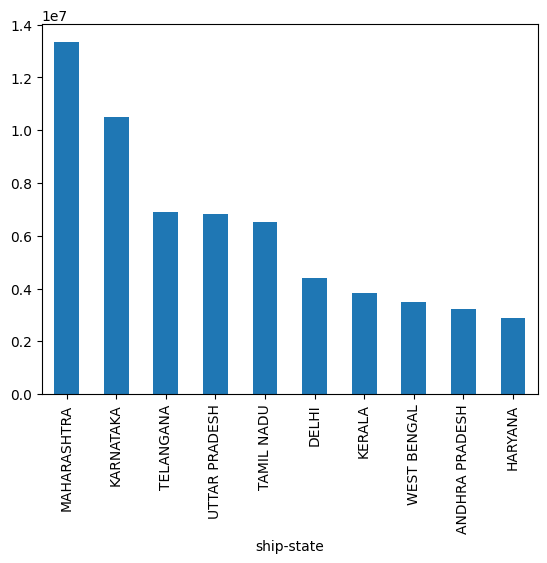

In [202]:
data.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

In [203]:
data.info()

<class 'pandas.DataFrame'>
Index: 128942 entries, 0 to 128974
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                128942 non-null  datetime64[us]
 1   Status              128942 non-null  str           
 2   Fulfilment          128942 non-null  str           
 3   Sales Channel       128942 non-null  str           
 4   ship-service-level  128942 non-null  str           
 5   Style               128942 non-null  str           
 6   SKU                 128942 non-null  str           
 7   Category            128942 non-null  str           
 8   Size                128942 non-null  str           
 9   ASIN                128942 non-null  str           
 10  Courier Status      122073 non-null  str           
 11  Qty                 128942 non-null  int64         
 12  Amount              121149 non-null  float64       
 13  ship-city           128942 non-null  str     

<Axes: xlabel='Style'>

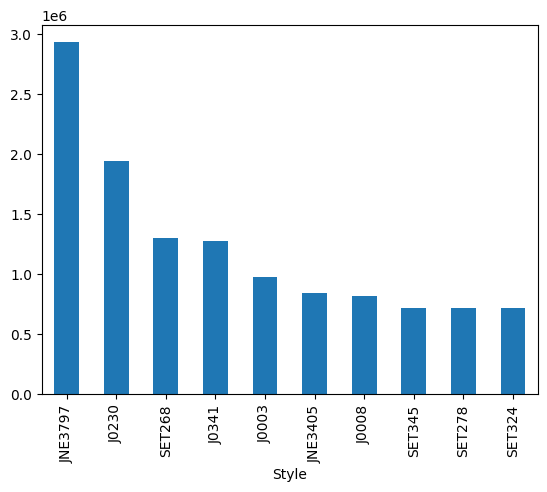

In [204]:
data.groupby('Style')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

In [205]:
data.groupby('Style')['Amount'].sum().sort_values(ascending=False).head(10)

Style
JNE3797    2932747.00
J0230      1943836.48
SET268     1303923.56
J0341      1275322.87
J0003       980665.75
JNE3405     846062.36
J0008       819169.96
SET345      723402.79
SET278      719791.48
SET324      719489.82
Name: Amount, dtype: float64

In [206]:
data['Status'] = data['Status'].str.upper().str.strip()

In [173]:
data['Status'].value_counts()

Status
SHIPPED                          77788
SHIPPED - DELIVERED TO BUYER     28762
CANCELLED                        18325
SHIPPED - RETURNED TO SELLER      1950
SHIPPED - PICKED UP                973
PENDING                            658
PENDING - WAITING FOR PICK UP      281
SHIPPED - RETURNING TO SELLER      145
SHIPPED - OUT FOR DELIVERY          35
SHIPPED - REJECTED BY BUYER         11
SHIPPING                             8
SHIPPED - LOST IN TRANSIT            5
SHIPPED - DAMAGED                    1
Name: count, dtype: int64

In [208]:
status_map = {"SHIPPED - PICKED UP": "SHIPPED/IN TRANSIT","SHIPPED":"SHIPPED/IN TRANSIT", "SHIPPED - OUT FOR DELIVERY":"SHIPPED/IN TRANSIT", "SHIPPED - DELIVERED TO BUYER":"DELIVERED", "CANCELLED":"RETURNED/CANCELLED", "SHIPPED - RETURNING TO SELLER": "RETURNED/CANCELLED", "SHIPPED - RETURNED TO SELLER":"RETURNED/CANCELLED", "SHIPPED - REJECTED BY BUYER":"RETURNED/CANCELLED", "SHIPPED - DAMAGED":"RETURNED/CANCELLED", "PENDING - WAITING FOR PICK UP":"PENDING", "SHIPPED - LOST IN TRANSIT":"LOST"}

In [209]:
data['Status'] = data['Status'].replace(status_map)

In [210]:
data['Status'].unique()

<StringArray>
['RETURNED/CANCELLED',          'DELIVERED', 'SHIPPED/IN TRANSIT',
               'LOST',            'PENDING',           'SHIPPING']
Length: 6, dtype: str